## Importing dataset and exploration

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
#Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

#Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('D:\SohamInternshipWork\datasets\playground-series-s4e2\ob_train.csv')


In [5]:
df['family_history_with_overweight'].value_counts()

family_history_with_overweight
yes    17014
no      3744
Name: count, dtype: int64

In [6]:
print(df.head())

   id  Gender        Age  ...       CALC                 MTRANS           NObeyesdad
0   0    Male  24.443011  ...  Sometimes  Public_Transportation  Overweight_Level_II
1   1  Female  18.000000  ...         no             Automobile        Normal_Weight
2   2  Female  18.000000  ...         no  Public_Transportation  Insufficient_Weight
3   3  Female  20.952737  ...  Sometimes  Public_Transportation     Obesity_Type_III
4   4    Male  31.641081  ...  Sometimes  Public_Transportation  Overweight_Level_II

[5 rows x 18 columns]


In [7]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(20758, 18)
<class 'pandas.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  str    
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  str    
 6   FAVC                            20758 non-null  str    
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  str    
 10  SMOKE                           20758 non-null  str    
 11  CH2O                            20758 non-null  float64
 12  SCC                            

In [8]:
# This gives idea of numeric and categorical variables 
print(df.select_dtypes(include='number').columns.tolist())
print(df.select_dtypes(include='object').columns.tolist())

['id', 'Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']


In [9]:
df.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [10]:
test_df = pd.read_csv('D:\SohamInternshipWork\datasets\playground-series-s4e2\ob_test.csv')

# Adding features

In [11]:
df['BMI'] = (
    df['Weight']/(df['Height']**2)
)

test_df['BMI'] = (
    test_df['Weight']/(test_df['Height']**2)
)

In [12]:
df['Energy_Balance'] = (
    df['FCVC'] *
    df['NCP']
) / (df['FAF'] + 1)

test_df['Energy_Balance'] = (
    test_df['FCVC'] *
    test_df['NCP']
) / (test_df['FAF'] + 1)

In [13]:
df['Sedentary_Score'] = (
    df['TUE'] +
    (3 - df['FAF'])
)

test_df['Sedentary_Score'] = (
    test_df['TUE'] +
    (3 - test_df['FAF'])
)

In [14]:
bins = [0, 18, 30, 45, 60, 100]

labels = [
    'Teen',
    'YoungAdult',
    'Adult',
    'MiddleAge',
    'Senior'
]

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

test_df['Age_Group'] = pd.cut(
    test_df['Age'],
    bins=bins,
    labels=labels
)

Seperating Features and targets 

In [15]:
X_df= df.drop("NObeyesdad",axis=1)
y_df =df['NObeyesdad'] #target variable

In [16]:
print(df["NObeyesdad"].value_counts())
# this gives the number of total categories in each type and also the number of rows under them.

NObeyesdad
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64


## Performing EDA on the dataset

Visualizing the distribution of unique categories in the target variable using countplot

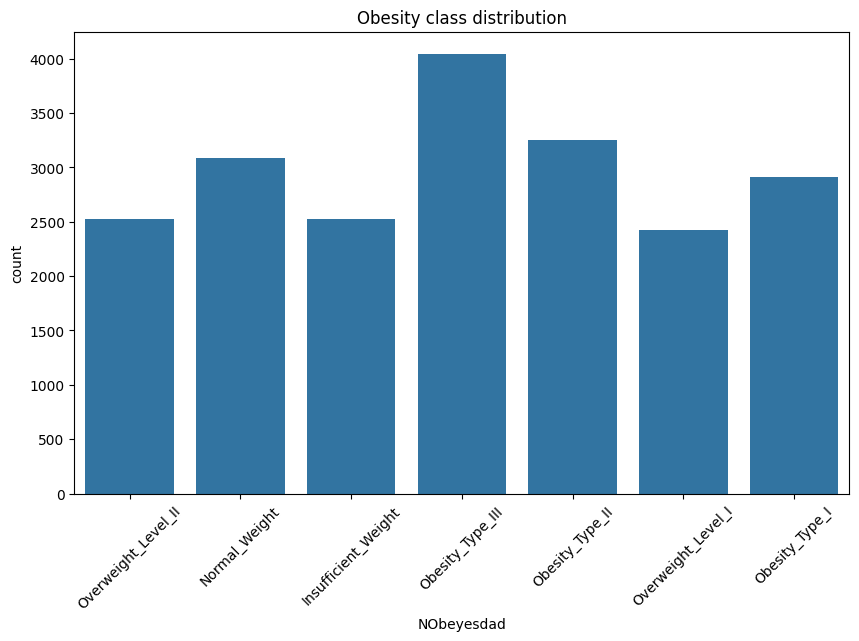

In [17]:
plt.figure(figsize=(10,6))

sns.countplot(
    data = df,
    x = 'NObeyesdad'
)

plt.xticks(rotation = 45)
plt.title("Obesity class distribution")
plt.show()

understanding the correlation of features 

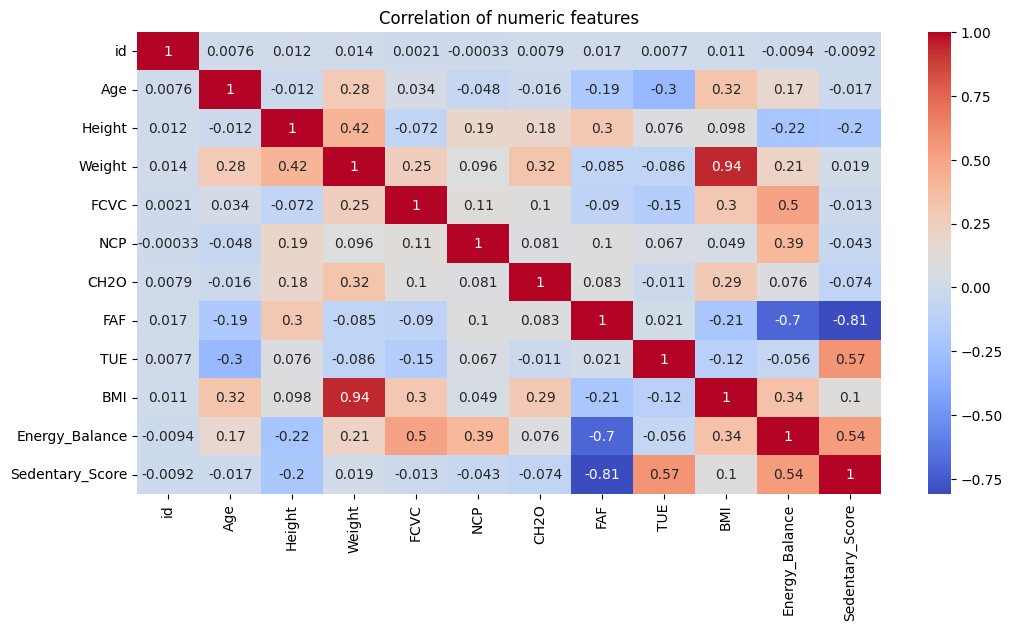

In [18]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot = True,
    cmap = 'coolwarm'
)

plt.title('Correlation of numeric features')
plt.show()

Inferences :
Strong correlations : Height and weight 
Slightly stong :    Weight and H20 consumption
Weak : FAFand height ; FCVC and Weight ; Age and weight 


## Drawing a comparison of distribution of weight and obesity

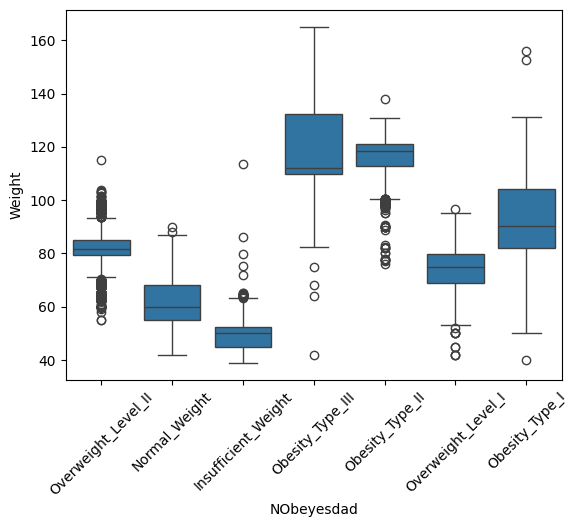

In [19]:
plt.Figure(figsize=(12, 8))

sns.boxplot(
    data = df,
    x='NObeyesdad',
    y='Weight',
)

plt.xticks(rotation = 45)
plt.show()

## Drawing a plot between physical activity and obesity

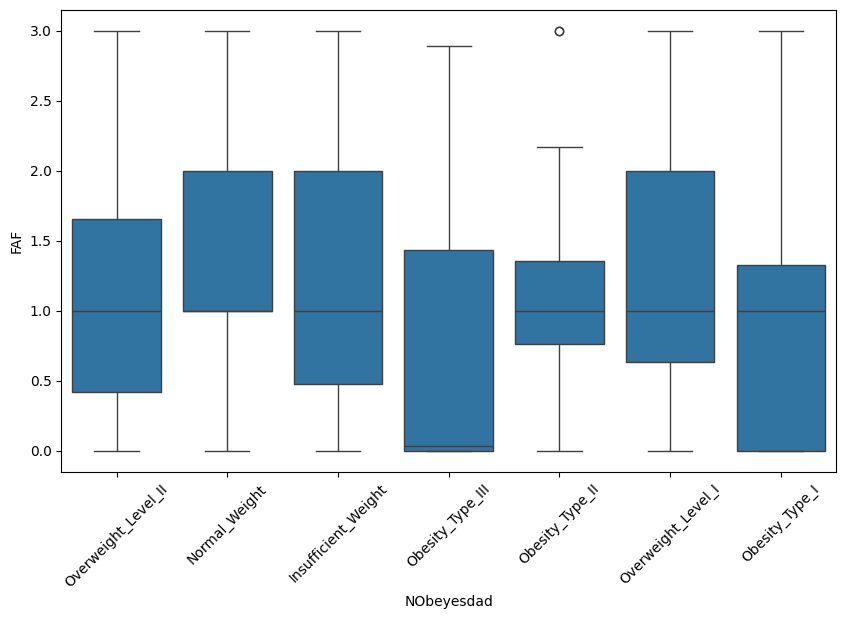

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='NObeyesdad',
    y='FAF'
)

plt.xticks(rotation=45)

plt.show()

Now features and target variables have been already seperated as X_df and y_df

NOTE : Drop ids from both the X_ df and also the test dataset

In [21]:
X_df = X_df.drop('id',axis = 1)
test_ids = test_df['id']
test_df = test_df.drop('id',axis=1)

In [22]:
#Group the categorical_columns and numerical columns into two seperate lists 
categorical_cols = X_df.select_dtypes(include=['object','str']).columns.tolist()
numerical_cols = X_df.select_dtypes(exclude=['object','str']).columns.tolist()
print(categorical_cols)
print(numerical_cols)

['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI', 'Energy_Balance', 'Sedentary_Score', 'Age_Group']


## Performing Label encode 

In [23]:
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y_df)

In [24]:
X_train, X_val,y_train ,y_val = train_test_split(
    X_df,
    y_encoded,
    test_size=0.2,
    stratify= y_encoded # this is important for maintaining the same proportion of the target variable as in the original dataset
) 

## Creating random forest pipeline

In [25]:
print(df["CAEC"].value_counts())
print(df["CALC"].value_counts())

CAEC
Sometimes     17529
Frequently     2472
Always          478
no              279
Name: count, dtype: int64
CALC
Sometimes     15066
no             5163
Frequently      529
Name: count, dtype: int64


In [26]:
ordinal_mapping = {
    'no': 0 ,
    'Sometimes' : 1,
    'Frequently' : 2,
    'Always': 3
}

In [27]:
X_train_rf = X_train.copy()
X_val_rf = X_val.copy()
test_rf = test_df.copy()

In [28]:
#ordinal encoding data ---> in this type of data the order matters hence it must be done through ordinal mapping
for col in ['CAEC', 'CALC']:
    X_train_rf[col] = X_train_rf[col].map(ordinal_mapping)
    X_val_rf[col] = X_val_rf[col].map(ordinal_mapping)
    test_rf[col] = test_rf[col].map(ordinal_mapping)

In [29]:
#binary mapping -> mapping the data as 1 or 0 ---> this must be done inorder to give a particular number to each class 
binary_map = {
    'yes': 1,
    'no': 0,
    'Male': 1,
    'Female': 0
}

binary_cols = [
     'Gender',
     'family_history_with_overweight',
     'FAVC',
     'SMOKE',
     'SCC'
 ]

for col in binary_cols:
    
    X_train_rf[col] = X_train_rf[col].map(binary_map)
    X_val_rf[col] = X_val_rf[col].map(binary_map)
    test_rf[col] = test_rf[col].map(binary_map)
 

In [30]:
# encoding remaining data as OHE 
X_train_rf = pd.get_dummies(
    X_train_rf,
    columns=['MTRANS','Age_Group'],
    drop_first=True
)

X_val_rf = pd.get_dummies(
    X_val_rf,
    columns=['MTRANS','Age_Group'],
    drop_first=True
)

test_rf = pd.get_dummies(
    test_rf,
    columns=['MTRANS','Age_Group'],
    drop_first=True
)

In [31]:
#column alignment 
X_train_rf, X_val_rf = X_train_rf.align(
    X_val_rf,
    join='left',
    axis=1,
    fill_value=0
)

X_train_rf, test_rf = X_train_rf.align(
    test_rf,
    join='left',
    axis=1,
    fill_value=0
)


In [32]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_rf,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
rf_preds = rf_model.predict(X_val_rf)

print("RF accuracy: ",
      accuracy_score(y_val,rf_preds)) # compares the actual data and the predictions and calculates deta in each casE

print(classification_report(y_val,rf_preds))

RF accuracy:  0.905587668593449
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       505
           1       0.86      0.89      0.88       617
           2       0.90      0.88      0.89       582
           3       0.96      0.97      0.97       650
           4       1.00      1.00      1.00       809
           5       0.79      0.77      0.78       485
           6       0.82      0.82      0.82       504

    accuracy                           0.91      4152
   macro avg       0.90      0.89      0.90      4152
weighted avg       0.91      0.91      0.91      4152



## Now using an XGB model

The pipeline stays the same as for random forest

In [34]:
xgb_model = XGBClassifier(
    n_estimators = 400,
    learning_rate = 0.03,
    max_depth = 6,
    objective='multi:softmax',
    num_class =len(np.unique(y_encoded)),
    random_state = 42 ,
)

xgb_model.fit(X_train_rf,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [35]:
xgb_preds = xgb_model.predict(X_val_rf)

print("XGB Accuracy:",
      accuracy_score(y_val, xgb_preds))

print(classification_report(
      y_val, 
      xgb_preds,
      target_names=target_encoder.classes_))

XGB Accuracy: 0.9108863198458574
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.94      0.94       505
      Normal_Weight       0.87      0.90      0.88       617
     Obesity_Type_I       0.90      0.90      0.90       582
    Obesity_Type_II       0.97      0.98      0.98       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.80      0.77      0.79       485
Overweight_Level_II       0.82      0.81      0.81       504

           accuracy                           0.91      4152
          macro avg       0.90      0.90      0.90      4152
       weighted avg       0.91      0.91      0.91      4152



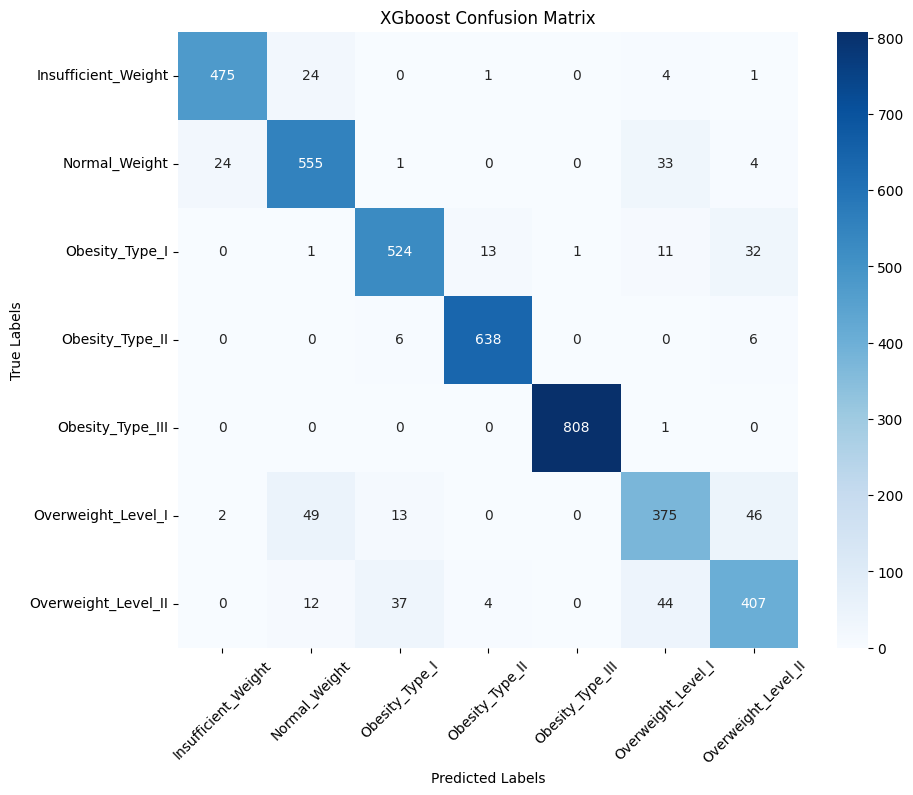

In [36]:
plt.figure(figsize=(10,8))

sns.heatmap(
    confusion_matrix(y_val, xgb_preds),
    annot=True,
    fmt='d',
    xticklabels = target_encoder.classes_,
    yticklabels = target_encoder.classes_,
    cmap = 'Blues'
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.title("XGboost Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

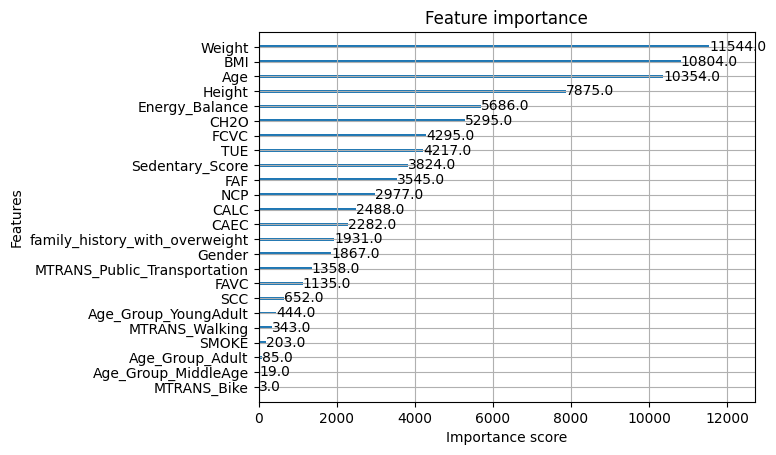

In [37]:
from xgboost import plot_importance
plot_importance(xgb_model)
plt.show()

Working with catboost

In [38]:
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
test_cat = test_df.copy()

In [39]:
cat_features = categorical_cols.append("Age_Group")

In [40]:
cat_features = X_train_cat.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(cat_features)

['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'Age_Group']


In [41]:
cat_model = CatBoostClassifier(
    iterations = 500,
    learning_rate = 0.05,
    depth = 6,
    loss_function = 'MultiClass',
    verbose = 100,
    random_state = 42
)

cat_model.fit(
    X_train_cat,
    y_train,
    cat_features = cat_features
)

0:	learn: 1.7636882	total: 504ms	remaining: 4m 11s
100:	learn: 0.3468766	total: 26.2s	remaining: 1m 43s
200:	learn: 0.2967145	total: 52s	remaining: 1m 17s
300:	learn: 0.2689681	total: 1m 18s	remaining: 52s
400:	learn: 0.2533888	total: 1m 44s	remaining: 25.9s
499:	learn: 0.2410733	total: 2m 11s	remaining: 0us


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, loss_function='MultiClass', random_state=42, verbose=100)

In [42]:
cat_preds = cat_model.predict(X_val_cat)
cat_preds = cat_preds.flatten()

print("Catboost accuracy: ", accuracy_score(y_val,cat_preds))
print(classification_report(y_val,cat_preds,target_names=target_encoder.classes_))

Catboost accuracy:  0.904383429672447
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.94      0.93       505
      Normal_Weight       0.87      0.88      0.88       617
     Obesity_Type_I       0.90      0.90      0.90       582
    Obesity_Type_II       0.97      0.98      0.97       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.78      0.75      0.77       485
Overweight_Level_II       0.81      0.81      0.81       504

           accuracy                           0.90      4152
          macro avg       0.89      0.89      0.89      4152
       weighted avg       0.90      0.90      0.90      4152



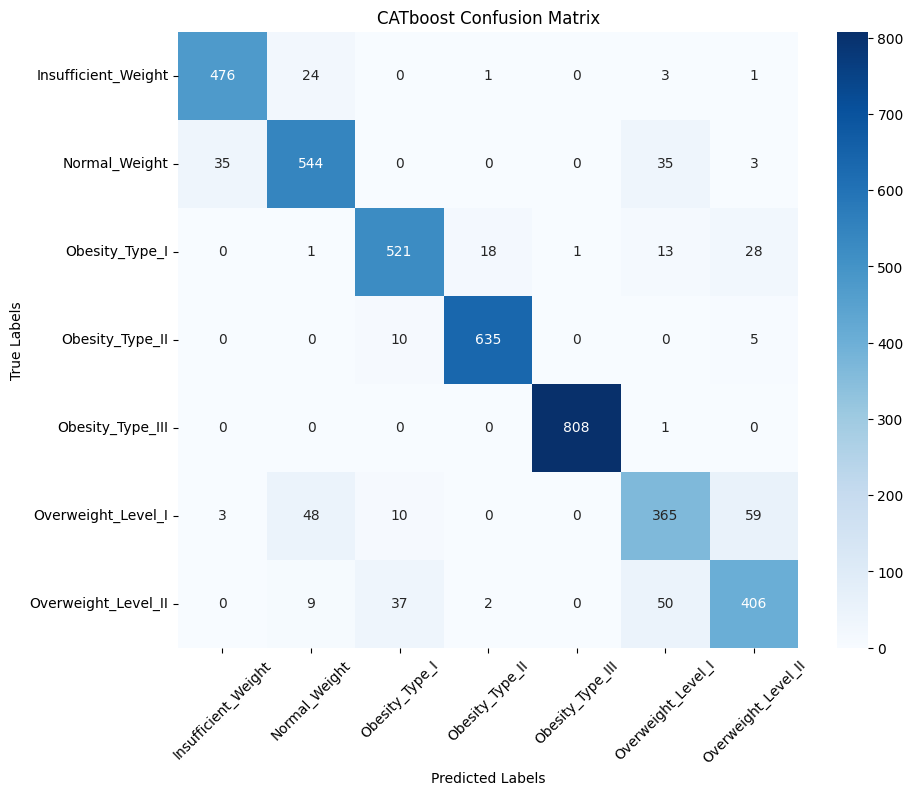

In [43]:
plt.figure(figsize=(10,8))

sns.heatmap(
    confusion_matrix(y_val, cat_preds),
    annot=True,
    fmt='d',
    xticklabels = target_encoder.classes_,
    yticklabels = target_encoder.classes_,
    cmap = 'Blues'
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.title("CATboost Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# Support Vector Machine

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_rf)
X_val_svm = scaler.transform(X_val_rf)
test_svm = scaler.transform(test_rf)

In [59]:
from sklearn.svm import SVC
svm_model = SVC(
    kernel='rbf',
    C=5,
    gamma='scale',
    decision_function_shape='ovr',   
    probability=True,
    random_state=42
)
svm_model.fit(X_train_svm, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [60]:
svm_preds = svm_model.predict(X_val_svm)
print("SVM Accuracy:", accuracy_score(y_val, svm_preds))
print(classification_report(y_val, svm_preds, target_names=target_encoder.classes_))

SVM Accuracy: 0.8725915221579962
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.91      0.91       505
      Normal_Weight       0.83      0.82      0.82       617
     Obesity_Type_I       0.87      0.85      0.86       582
    Obesity_Type_II       0.96      0.96      0.96       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.73      0.69      0.71       485
Overweight_Level_II       0.73      0.78      0.75       504

           accuracy                           0.87      4152
          macro avg       0.86      0.86      0.86      4152
       weighted avg       0.87      0.87      0.87      4152



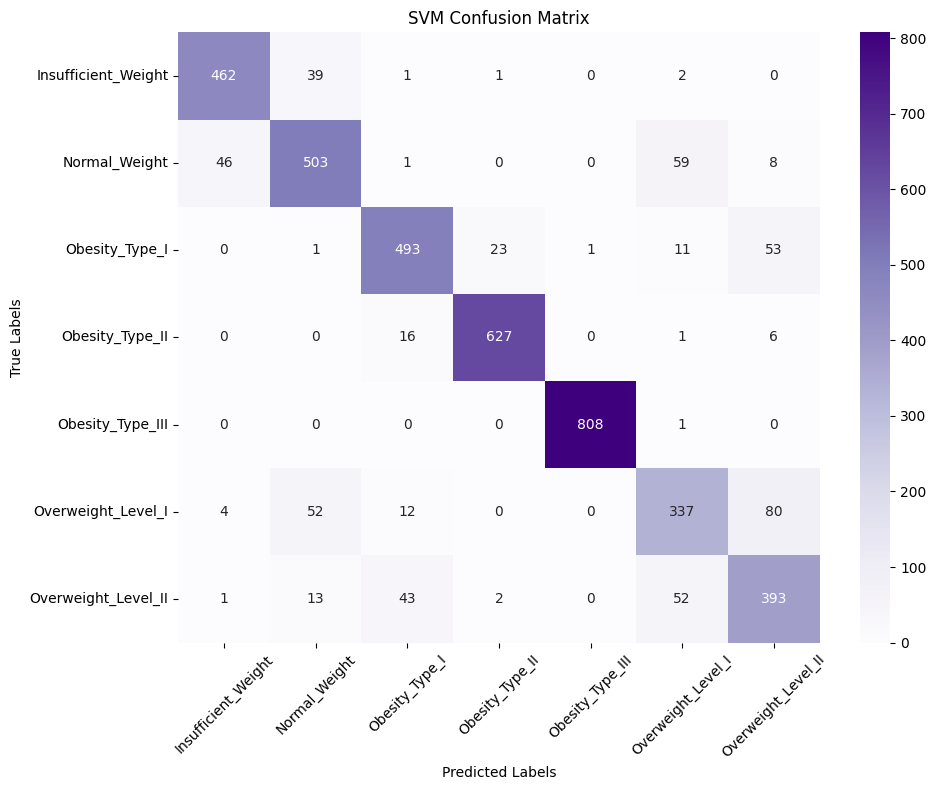

In [61]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion_matrix(y_val, svm_preds),
    annot=True, fmt='d',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_,
    cmap='Purples'
)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("SVM Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'CatBoost', 'SVM'],
    'Accuracy': [
        accuracy_score(y_val, rf_preds),
        accuracy_score(y_val, xgb_preds),
        accuracy_score(y_val, cat_preds),
        accuracy_score(y_val, svm_preds),
    ]
})
print(results)

           Model  Accuracy
0  Random Forest  0.905588
1        XGBoost  0.910886
2       CatBoost  0.904383
3            SVM  0.872592


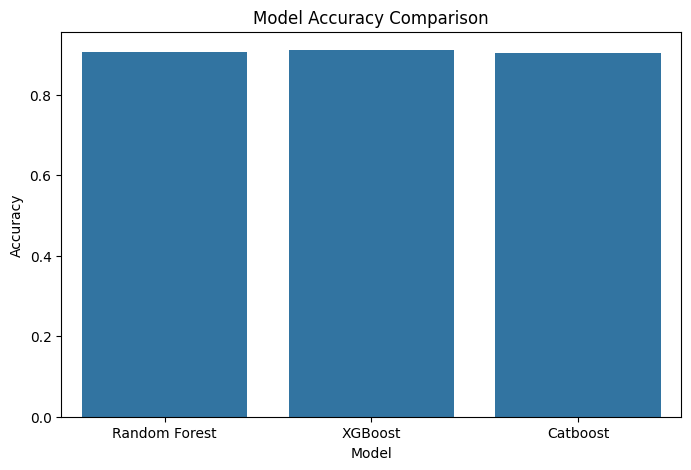

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title("Model Accuracy Comparison")

plt.show()

In [63]:
old_rf_acc  = 0.902697
old_xgb_acc = 0.903902
old_cat_acc = 0.899566
old_svm_acc = 0.875000

# Changes after feature engineering 

In [64]:
new_rf = accuracy_score(y_val, rf_preds)

new_xgb = accuracy_score(y_val, xgb_preds)

new_cat = accuracy_score(y_val, cat_preds)
new_svm = accuracy_score(y_val,svm_preds)

In [65]:
comparison_df = pd.DataFrame({
    'Model':     ['Random Forest', 'XGBoost', 'CatBoost', 'SVM'],
    'Before_FE': [old_rf_acc, old_xgb_acc, old_cat_acc, old_svm_acc],
    'After_FE':  [new_rf,     new_xgb,     new_cat,     new_svm],
})
print(comparison_df)

           Model  Before_FE  After_FE
0  Random Forest   0.902697  0.905588
1        XGBoost   0.903902  0.910886
2       CatBoost   0.899566  0.904383
3            SVM   0.875000  0.872592


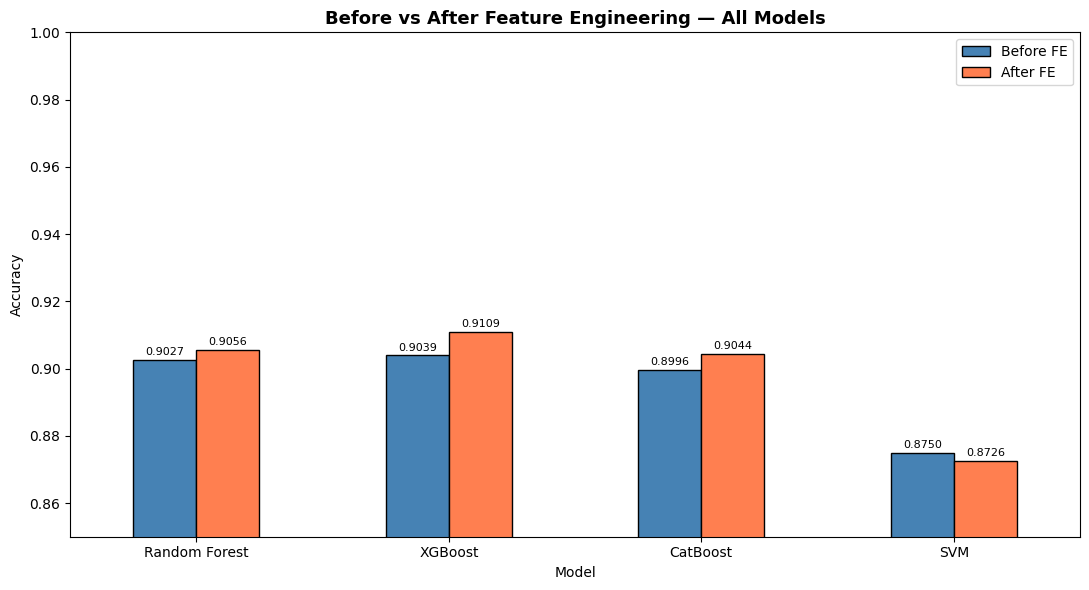

In [66]:
ax = comparison_df.plot(x='Model', kind='bar', figsize=(11, 6),
                        color=['steelblue', 'coral'], edgecolor='black')
plt.ylabel("Accuracy")
plt.title("Before vs After Feature Engineering — All Models", fontsize=13, fontweight='bold')
plt.xticks(rotation=0)
plt.ylim(0.85, 1.0)
plt.legend(['Before FE', 'After FE'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

Hence we have correctly performed the predictions and have compared the models before and after feature engineering.

In [51]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

In [52]:
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_model,
    X_train_rf,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

In [53]:
print("Fold Accuracies:")

print(scores)

print("Mean Accuracy:")

print(scores.mean())

Fold Accuracies:
[0.90276942 0.90545017 0.89521229 0.89822343 0.90876242]
Mean Accuracy:
0.9020835429439316


In [54]:
final_preds = xgb_model.predict(test_rf)
final_preds = final_preds.flatten()

In [55]:
final_labels = target_encoder.inverse_transform(
    final_preds.astype(int)
)

In [56]:
submission = pd.DataFrame({
    'id': test_ids,
    'NObeyesdad': final_labels
})

submission.to_csv(
    'final_predictions.csv',
    index=False
)

print("Final_predictions created successfully !!")

Final_predictions created successfully !!


# Hence , it can be concluded that the dataset has officially hit the ceiling as all three models have about the similar kind of performance which indicates that it reaching the point of saturation . XGboost performed relatively better in the cases
